# K05_00 – Logistische Regression: Äpfel-Beispiel

## Lernziele
- binäre Klassifikation verstehen
- Wahrscheinlichkeiten und Klassenentscheidungen unterscheiden
- die Rolle der Sigmoid-Funktion intuitiv einordnen
- Accuracy und Konfusionsmatrix interpretieren

Wir betrachten ein einfaches Beispiel:
Ein Apfel wird anhand eines Merkmals klassifiziert.

- **Klasse 0**: noch nicht genießbar
- **Klasse 1**: genießbar

## 1. Bibliotheken importieren
Wir verwenden `LogisticRegression` aus `scikit-learn`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

## 2. Beispieldaten erzeugen

Das Merkmal ist hier stark vereinfacht ein Reifeindikator zwischen 0 und 15.
Kleine Werte sprechen eher für Klasse 0, größere Werte eher für Klasse 1.

In [2]:
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])

print("Shape von X:", X.shape)
print("Shape von y:", y.shape)
print("X:", X.ravel())
print("y:", y)

Shape von X: (14, 1)
Shape von y: (14,)
X: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
y: [0 0 0 0 0 0 1 0 1 1 1 1 1 1]


## 3. Daten visualisieren

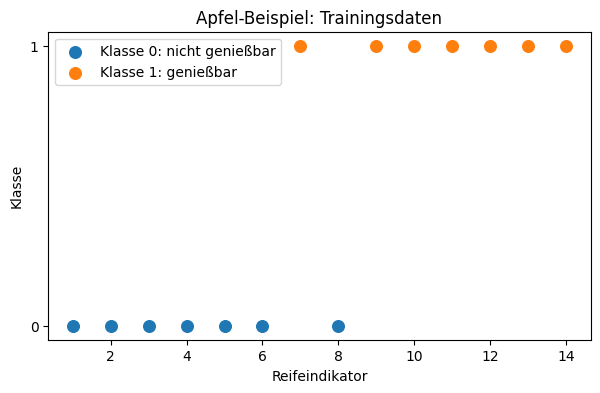

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(X[y == 0], y[y == 0], label="Klasse 0: nicht genießbar", s=70)
plt.scatter(X[y == 1], y[y == 1], label="Klasse 1: genießbar", s=70)
plt.xlabel("Reifeindikator")
plt.ylabel("Klasse")
plt.yticks([0, 1])
plt.legend()
plt.title("Apfel-Beispiel: Trainingsdaten")
plt.show()

## 4. Modell trainieren
Wir trainieren jetzt eine logistische Regression.

In [4]:
clf = LogisticRegression()
clf.fit(X, y)

print("Intercept:", clf.intercept_[0])
print("Koeffizient:", clf.coef_[0, 0])

Intercept: -6.957332749368031
Koeffizient: 0.9276468592239987


## 5. Wahrscheinlichkeiten berechnen
Die logistische Regression sagt zunächst **Wahrscheinlichkeiten** voraus.
Erst danach wird daraus eine Klasse 0 oder 1 abgeleitet.

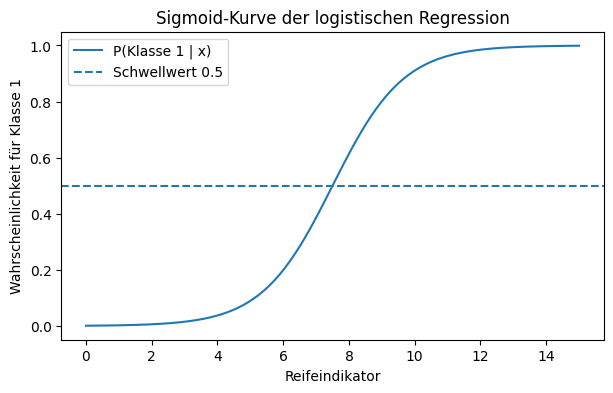

In [5]:
X_test = np.linspace(0, 15, 300).reshape(-1, 1)
proba = clf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(7, 4))
plt.plot(X_test, proba, label="P(Klasse 1 | x)")
plt.axhline(0.5, linestyle="--", label="Schwellwert 0.5")
plt.xlabel("Reifeindikator")
plt.ylabel("Wahrscheinlichkeit für Klasse 1")
plt.title("Sigmoid-Kurve der logistischen Regression")
plt.legend()
plt.show()

## 6. Klassenentscheidung und Entscheidungsgrenze
Mit `predict()` wird aus der Wahrscheinlichkeit eine Klassenentscheidung.

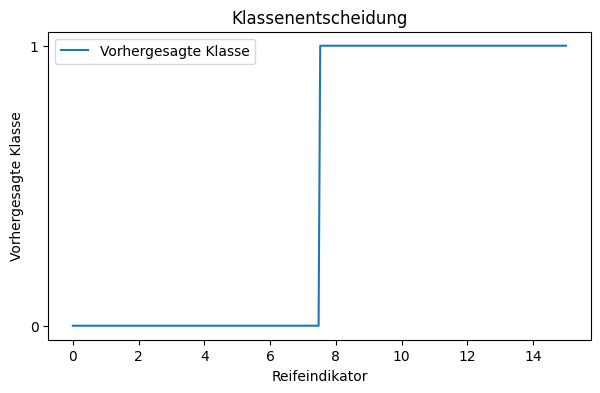

In [6]:
pred_curve = clf.predict(X_test)

plt.figure(figsize=(7, 4))
plt.plot(X_test, pred_curve, label="Vorhergesagte Klasse")
plt.xlabel("Reifeindikator")
plt.ylabel("Vorhergesagte Klasse")
plt.yticks([0, 1])
plt.title("Klassenentscheidung")
plt.legend()
plt.show()

## 7. Evaluation auf den vorhandenen Beispielen
Zur Veranschaulichung bewerten wir das Modell zunächst auf den vorhandenen Daten.

In [7]:
y_pred = clf.predict(X)

acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print("Accuracy :", round(acc, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-Score :", round(f1, 3))
print("\nKonfusionsmatrix:\n", cm)

Accuracy : 0.857
Precision: 0.857
Recall   : 0.857
F1-Score : 0.857

Konfusionsmatrix:
 [[6 1]
 [1 6]]


## 8. Kleine Übung

**Aufgabe 1:**  
Bestimmen Sie mit `predict_proba()` die Wahrscheinlichkeit für Klasse 1 für die Werte 5, 7 und 10.

**Aufgabe 2:**  
Erklären Sie in Worten:
- Warum ist 0,5 ein sinnvoller Standardschwellwert?
- Warum liefert die logistische Regression zunächst Wahrscheinlichkeiten und nicht direkt Klassen?

In [8]:
# TODO: Berechnen Sie die Wahrscheinlichkeiten für x = 5, 7 und 10.
# beispiel = np.array([[5], [7], [10]])
# ...

## 9. Reflexion
- Was unterscheidet `predict_proba()` von `predict()`?
- In welchem Bereich liegen die Ausgaben der Sigmoid-Funktion?
- Welche Rolle spielt der Schwellwert?